<a href="https://colab.research.google.com/github/fatihonay/Neural-Variability-/blob/main/docs/source/Tutorials/MPI_LEMON.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# From Surface to Deep: Source Level Analysis

Preprocessing was performed as follows. Raw EEG data were downsampled from 2500 Hz to 250 Hz and band-pass filtered between 1 and 45 Hz using a fourth-order Butterworth filter. Raw activity traces were visually inspected, and electrodes exhibiting frequency drifts, voltage shifts, or poor signal quality were excluded. The data were further inspected for intervals containing extreme peak-to-peak deflections or large bursts of high-frequency activity, and such intervals were discarded.

To reduce the dimensionality of the EEG signals, principal component analysis (PCA) was applied, retaining components that explained 95% of the total variance. Independent component analysis (ICA) based on the Extended Infomax algorithm was then performed. Components reflecting eye movements, eye blinks, muscle activity, or heartbeat-related artifacts were identified by visual inspection and removed.


In [2]:
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 62.4 MB/s eta 0:00:00


In [3]:
import mne
import os
import numpy as np
from mne.minimum_norm import make_inverse_operator, apply_inverse_raw
from mne.datasets import fetch_fsaverage

# 1. Load Data
file_path = '/content/drive/MyDrive/MPI-LEMON/sub-032301/sub-032301_EC.set'
raw       = mne.io.read_raw_eeglab(file_path, preload=True)

# OPTIMIZATION 1: Resample to 100Hz
print(f"Original sampling rate: {raw.info['sfreq']} Hz")
raw.resample(100)
print(f"New sampling rate: {raw.info['sfreq']} Hz")

# OPTIMIZATION 2: Crop to 60 seconds
raw.crop(tmin=0, tmax=60)

# 2. Standard Preprocessing
raw.set_montage('standard_1020')
raw.set_eeg_reference('average', projection=True) # CAR Filtering

# 3. Setup Forward Model
fs_dir       = fetch_fsaverage(verbose=False)
subjects_dir = os.path.dirname(fs_dir)

src = mne.setup_source_space('fsaverage', spacing='oct6', add_dist='patch',
                             subjects_dir=subjects_dir)

model = mne.make_bem_model(subject='fsaverage', ico=4,
                           conductivity=(0.3, 0.006, 0.3),
                           subjects_dir=subjects_dir)
bem = mne.make_bem_solution(model)

fwd = mne.make_forward_solution(raw.info, trans='fsaverage', src=src, bem=bem,
                                eeg=True, mindist=5.0, n_jobs=1)

# 4. Compute Covariance & Inverse
cov              = mne.compute_raw_covariance(raw, tmin=0, tmax=None, method='auto', rank=None)
inverse_operator = make_inverse_operator(raw.info, fwd, cov, loose=0.2, depth=0.8)

# 5. Apply eLORETA
snr = 3.0
lambda2 = 1.0 / snr ** 2
method = "eLORETA"

# This should now run comfortably within RAM limits
stc = apply_inverse_raw(raw, inverse_operator, lambda2,
                        method=method, pick_ori=None,
                        verbose=True)

print("SUCCESS: Source localization complete without crashing!")

# 6. Extract Results for Regions of Interest
# Load the atlas labels
labels = mne.read_labels_from_annot('fsaverage', parc='aparc', subjects_dir=subjects_dir)

# Define regions
regions_of_interest = [
    'caudalmiddlefrontal-lh', # Frontal
    'lateraloccipital-lh',    # Occipital
    'precentral-lh',          # Motor
    'superiortemporal-lh',    # Temporal
    'postcentral-lh'          # Parietal
]

print("\n--- eLORETA Mean Activation (60s average) ---")
for region in regions_of_interest:
    label_obj = [l for l in labels if l.name == region][0]
    # Extract
    roi_data = stc.extract_label_time_course(label_obj, src, mode='mean_flip')
    # Average over time
    mean_val = np.mean(np.abs(roi_data))
    print(f"{region}: {mean_val:.4e}")



Reading /content/drive/MyDrive/MPI-LEMON/sub-032301/sub-032301_EC.fdt


/tmp/ipython-input-110955098.py:9: RuntimeWarning: Data file name in EEG.data (sub-010002_EC.fdt) is incorrect, the file name must have changed on disk, using the correct file name (sub-032301_EC.fdt).
  raw       = mne.io.read_raw_eeglab(file_path, preload=True)


Reading 0 ... 119344  =      0.000 ...   477.376 secs...


/tmp/ipython-input-110955098.py:9: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw       = mne.io.read_raw_eeglab(file_path, preload=True)
/tmp/ipython-input-110955098.py:9: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw       = mne.io.read_raw_eeglab(file_path, preload=True)


Original sampling rate: 250.0 Hz
New sampling rate: 100.0 Hz
EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.


Setting up the source space with the following parameters:

SUBJECTS_DIR = /root/mne_data/MNE-fsaverage-data
Subject      = fsaverage
Surface      = white
Octahedron subdivision grade 6

>>> 1. Creating the source space...

Doing the octahedral vertex picking...
Loading /root/mne_data/MNE-fsaverage-data/fsaverage/surf/lh.white...
Mapping lh fsaverage -> oct (6) ...
    Triangle neighbors and vertex normals...
Loading geometry from /root/mne_data/MNE-fsaverage-data/fsaverage/surf/lh.sphere...
Setting up the triangulation for the decimated surface...
loaded lh.white 4098/163842 selected to source space (oct = 6)

Loading /root/mne_data/MNE-fsaverage-data/fsaverage/surf/rh.white...
Mapping rh fsaverage -> oct (6) ...
    Triangle neighbors and vertex normals...
Loading geometry from /root/mne_data/MNE-fsaverage-data/fsaverage/surf/rh.sphere...
Setting up the triangulation for the decimated surface...
loaded rh.white 4098/163842 selected to source space (oct = 6)

Calculating patch informa

Plotting Left Hemisphere (Scaled)...
Octahedron subdivision grade 6
    Triangle neighbors and vertex normals...
Loading geometry from /root/mne_data/MNE-fsaverage-data/fsaverage/surf/lh.sphere...
Setting up the triangulation for the decimated surface...
    5 smooth iterations done.


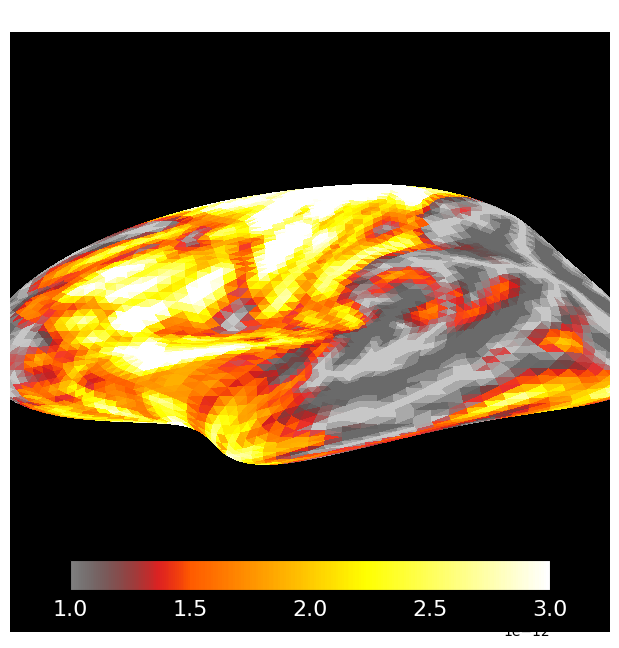

Plotting Right Hemisphere (Scaled)...
Octahedron subdivision grade 6
    Triangle neighbors and vertex normals...
Loading geometry from /root/mne_data/MNE-fsaverage-data/fsaverage/surf/rh.sphere...
Setting up the triangulation for the decimated surface...
    5 smooth iterations done.


<Figure size 640x480 with 0 Axes>

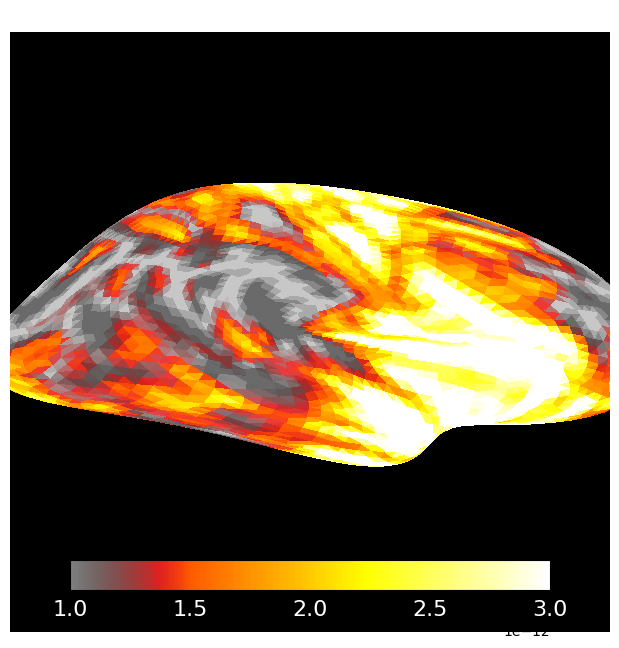

SUCCESS: Check the new images. You should see red/yellow activation now.


<Figure size 640x480 with 0 Axes>

In [4]:
import matplotlib.pyplot as plt

# 1. Define the correct scale for YOUR data
# -----------------------------------------
# Your max value was ~1.9e-12.
# We set limits at:
#   - 0.5e-12 (faint activity)
#   - 1.0e-12 (medium activity)
#   - 2.0e-12 (peak activity)
data_limits = dict(kind='value', lims=[1e-12, 1.50e-12, 3.0e-12])

# 2. Plot Left Hemisphere with manual scaling
# -------------------------------------------
print("Plotting Left Hemisphere (Scaled)...")
brain_lh = stc.plot(subject='fsaverage', subjects_dir=subjects_dir,
                    initial_time=10.0, hemi='lh',
                    views='lat',
                    smoothing_steps=5,
                    backend='matplotlib',
                    clim=data_limits,       # <--- The Critical Fix
                    time_viewer=False,
                    title='Left Hemisphere (Corrected Scale)')

plt.savefig('eLORETA_Left_Hemi_Corrected.png', dpi=300)

# 3. Plot Right Hemisphere with manual scaling
# --------------------------------------------
print("Plotting Right Hemisphere (Scaled)...")
brain_rh = stc.plot(subject='fsaverage', subjects_dir=subjects_dir,
                    initial_time=10.0, hemi='rh',
                    views='lat',
                    smoothing_steps=5,
                    backend='matplotlib',
                    clim=data_limits,       # <--- The Critical Fix
                    time_viewer=False,
                    title='Right Hemisphere (Corrected Scale)')

plt.savefig('eLORETA_Right_Hemi_Corrected.png', dpi=300)

print("SUCCESS: Check the new images. You should see red/yellow activation now.")